In [44]:
import sqlite3
import pandas as pd

sql_conn = sqlite3.connect("valorant.sqlite")

game_rounds = pd.read_sql_query("Select * from Game_Rounds", con=sql_conn)
game_rounds.dropna(inplace=True)
game_rounds.reset_index(inplace=True)

#### Collecting the data

In [126]:
import collections

win_type = {'elim': 0,
           'boom': 0,
           'defuse': 0,
           "time": 0}

buy_type = {"eco": 0,
           "semi-eco": 0,
           "semi-buy": 0,
           "full-buy": 0}

win_score = collections.defaultdict(int)


for key1,value1 in game_rounds["RoundHistory"].items():
    for key2,value2 in eval(value1).items():
        buy_type[value2['Team1BuyType']] += 1
        buy_type[value2['Team2BuyType']] += 1
        
        win_type[value2["WinType"]] += 1
        
    win_score[value2["ScoreAfterRound"]] += 1
        

In [127]:
buy_type

{'eco': 88190, 'semi-eco': 44516, 'semi-buy': 129401, 'full-buy': 348055}

In [128]:
win_type

{'elim': 215681, 'boom': 21863, 'defuse': 60834, 'time': 6703}

#### Syncing different scores (like: 13-7 and 7-13)

In [129]:
delete_keys = []

for key,value in win_score.items():
    if len(key) == 4:
        if key[1] == "-":
            new_key = key[2:] + "-" + key[0]
            win_score[new_key] += value
            delete_keys.append(key)
    elif len(key) == 5:
        if int(key[:2]) < int(key[3:]):
            new_key = key[3:] + "-" + key[:2]
            win_score[new_key] += value
            delete_keys.append(key)


for key in delete_keys:
    win_score.pop(key)

print(win_score)

defaultdict(<class 'int'>, {'13-7': 1527, '13-8': 1417, '13-6': 1411, '13-9': 1518, '13-4': 1090, '13-3': 916, '13-2': 699, '14-12': 664, '13-11': 1551, '13-1': 444, '13-5': 1239, '13-10': 1495, '15-13': 326, '13-0': 158, '16-14': 183, '14-13': 1, '17-15': 101, '18-4': 1, '18-16': 49, '13-13': 1, '15-6': 1, '22-20': 4, '19-17': 20, '14-14': 2, '21-19': 2, '16-7': 1, '14-4': 2, '16-8': 2, '20-18': 5, '13-12': 8, '0-8': 1, '14-8': 1, '14-10': 2, '5-6': 1, '17-7': 2, '14-9': 2, '14-7': 1, '15-2': 1, '16-5': 1, '12-12': 2, '14-3': 1, '17-6': 1})


#### Sharing the analize

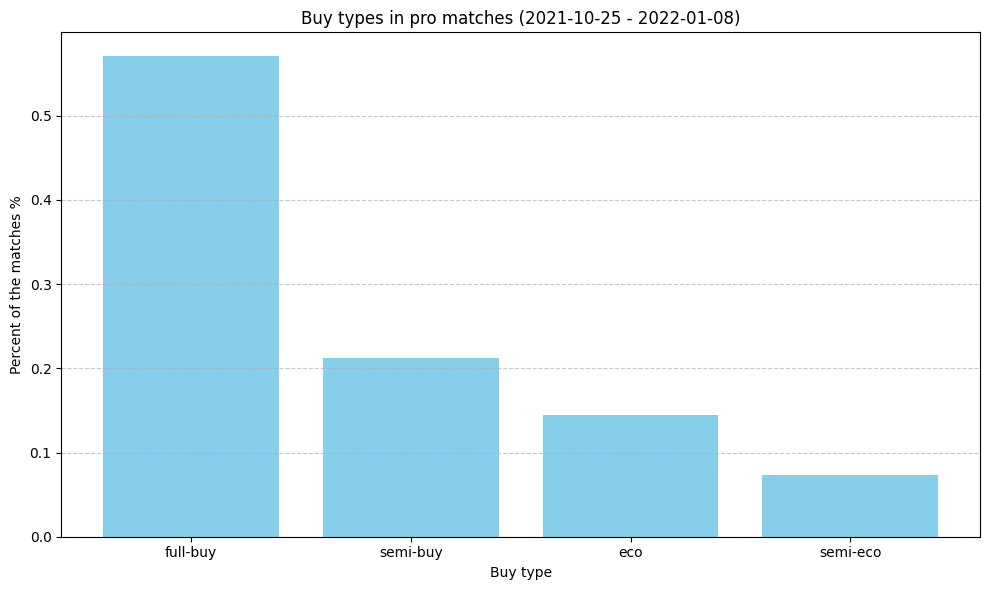

In [160]:
import matplotlib.pyplot as plt

sorted_buy_type = dict(sorted(buy_type.items(), key=lambda item: item[1], reverse=True))

buys = sum(buy_type.values())

sorted_buy_type_perc = sorted_buy_type.copy()

for key, value in sorted_buy_type_perc.items():
    sorted_buy_type_perc[key] = value/buys


plt.figure(figsize=(10, 6))
plt.bar(sorted_buy_type_perc.keys(),sorted_buy_type_perc.values() , color='skyblue')
plt.title('Buy types in pro matches (2021-10-25 - 2022-01-08)')
plt.xlabel('Buy type')
plt.ylabel('Percent of the matches %')
plt.xticks()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

{'13-11': 1551, '13-7': 1527, '13-9': 1518, '13-10': 1495, '13-8': 1417, '13-6': 1411, '13-5': 1239, '13-4': 1090, '13-3': 916, '13-2': 699, '14-12': 664, '13-1': 444, '15-13': 326, '16-14': 183, '13-0': 158, '17-15': 101, '18-16': 49, '19-17': 20, '13-12': 8, '20-18': 5, '22-20': 4, '14-14': 2, '21-19': 2, '14-4': 2, '16-8': 2, '14-10': 2, '17-7': 2, '14-9': 2, '12-12': 2, '14-13': 1, '18-4': 1, '13-13': 1, '15-6': 1, '16-7': 1, '0-8': 1, '14-8': 1, '5-6': 1, '14-7': 1, '15-2': 1, '16-5': 1, '14-3': 1, '17-6': 1}


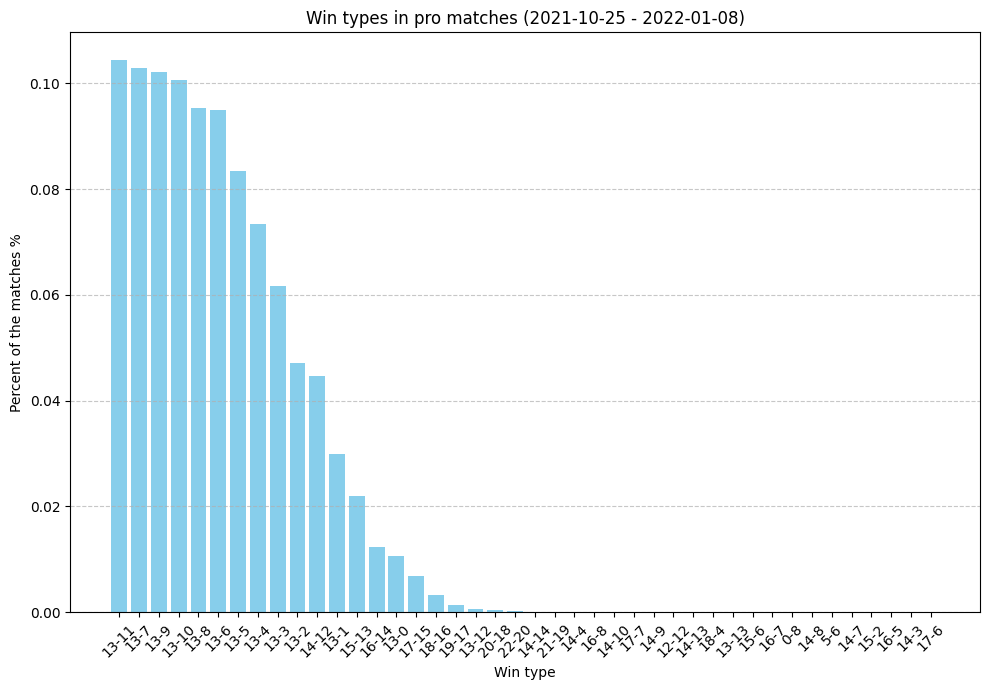

In [ ]:

sorted_win_score = dict(sorted(win_score.items(), key=lambda item: item[1], reverse=True))

sorted_win_score_perc = sorted_win_score.copy()

win_sum = sum(sorted_win_score.values())
for key, value in sorted_win_score_perc.items():
    sorted_win_score_perc[key] = value/win_sum
    



plt.figure(figsize=(10, 7))
plt.bar(sorted_win_score_perc.keys(),sorted_win_score_perc.values() , color='skyblue')
plt.title('Win scores in pro matches (2021-10-25 - 2022-01-08)')
plt.xlabel('Win type')
plt.ylabel('Percent of the matches %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

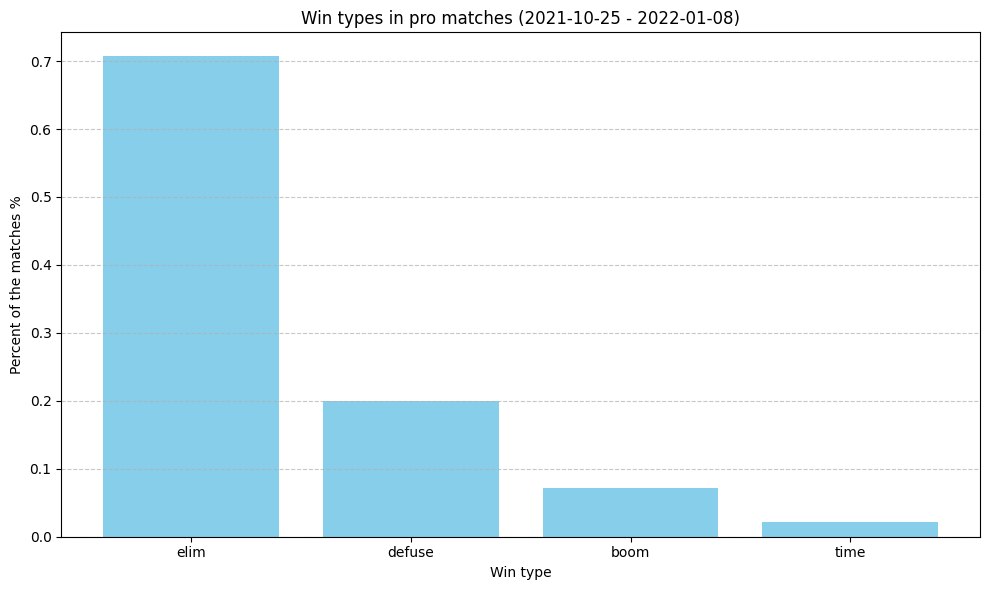

In [161]:
sorted_win_type = dict(sorted(win_type.items(), key=lambda item: item[1], reverse=True))

wins = sum(win_type.values())

sorted_win_type_perc = sorted_win_type.copy()

for key, value in sorted_win_type_perc.items():
    sorted_win_type_perc[key] = value/wins
    

plt.figure(figsize=(10, 6))
plt.bar(sorted_win_type_perc.keys(),sorted_win_type_perc.values() , color='skyblue')
plt.title('Win types in pro matches (2021-10-25 - 2022-01-08)')
plt.xlabel('Win type')
plt.ylabel('Percent of the matches %')
plt.xticks()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()